In [1]:
import sys, math, warnings, time
from pathlib import Path
from copy import deepcopy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp
warnings.filterwarnings("ignore")
# Resolve project root so the project modules import cleanly
project_folder_name = "MFC2024"
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents]
                     if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
# Project imports
from config.settings    import solver_variable_names, solver_flux_names
from config.initialize  import parameters, operating_inputs, init_x_for
from model.model    import PEMFC
from model.kinetic_eq   import Rproton, eta_ccl, fdrop
from model.coefficients import *


In [2]:
# Sweep grid used to pick experimental points to compare against
I_tested   = [10, 20, 30, 35, 40]      # A      current points
TFC_tested = [50, 60, 70]              # degC   cell temperature
PAC_tested = [1.3e5, 1.4e5, 1.5e5]     # Pa     anode/cathode pressure
RHC_tested = [0, 50]                   # %      cathode relative humidity

In [3]:
# ---- Cell 2: Import experiment data ----
exp_file       = project_root / "data" / "Polar_curves.xlsx"
polardata_exp  = pd.read_excel(exp_file, sheet_name=None)

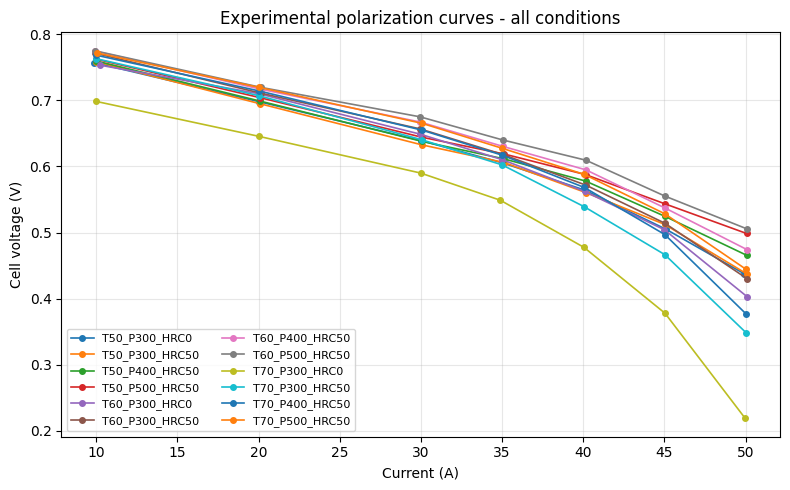

In [4]:
# ---- Cell 3: Plot the experimental data ----
fig, ax = plt.subplots(figsize=(8, 5))
for name, df in polardata_exp.items():
    i_exp = df["I_LOAD"].to_numpy(dtype=float)
    v_exp = df["VFC"].to_numpy(dtype=float) / n_cell
    ax.plot(i_exp, v_exp, "o-", linewidth=1.2, markersize=4, label=name)

ax.set_xlabel("Current (A)")
ax.set_ylabel("Cell voltage (V)")
ax.set_title("Experimental polarization curves - all conditions")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc="best", ncol=2)
plt.tight_layout()
plt.show()

In [5]:
# ---- Cell 4: Setup the undetermined parameters ----
#
# All 15 entries below are the best_params exported from the GUI's
# Calibration page after the 50-trial, transient (PEMFC + BDF) run against
# Polarization data — file `2026-07-01T11-43_export.csv`. This is a full
# parameter sweep (every entry was in PARAMS_TO_FIT), so nothing here is
# hand-tuned any more.
#
# To refresh with a newer calibration:
#   * open the Calibration page in the GUI, run a calibration, click the
#     export/copy button under "Best parameters", and paste the new CSV
#     into a file, OR
#   * re-run `python calibration.py` (with SAVE_RESULT=True) and copy
#     the values from `calibration_result.json`.
#
# The GUI's transient calibration (Dynamic + Aux off + BDF) evaluates the
# exact same PEMFC transient model as this notebook, so with the same
# numeric values the polarization curves must match.
manual_params = {
    "OCV":          0.9919379835702692,     # V        open-circuit voltage
    "i0_c_ref":     0.44500462644885697,    # A/m^2    cathode exchange current density (ref)
    "kappa_c":      2.8147526233431135,     # -        O2 reaction order
    "epsilon_mc":   0.47233517181586926,    # -        ionomer fraction in micro CL
    "epsilon_c":    0.12278001453740726,    # -        cathode ionomer fraction
    "epsilon_cl":   0.4490759763619542,     # -        catalyst-layer porosity
    "Hcl":          1.0281156106032969e-05, # m        catalyst-layer thickness
    "Hgdl":         0.00027562518550491974, # m        GDL thickness
    "e":            5,                      # -        Bruggeman exponent (discrete)
    "tau":          2.2789574546285536,     # -        GDL tortuosity exponent
    "Re":           2.081592241675901e-06,  # Ohm.m^2  electronic resistance
    "epsilon_gdl":  0.6422197300301392,     # -        GDL porosity
    "a_slim":       0.16338411791093982,    # -        saturation-switch slope
    "b_slim":       0.20255510316911263,    # -        saturation-switch intercept
    "a_switch":     0.09326886381432659,    # -        saturation-switch threshold
}

dwell_polar = 60.0  # seconds held at each current level

In [6]:
def match_experimental_points(i_exp, v_exp, i_targets):
    """Pick one experimental point per simulated current target."""
    if not i_targets:
        return np.array([], dtype=float), np.array([], dtype=float)
    i_exp = np.asarray(i_exp, dtype=float)
    v_exp = np.asarray(v_exp, dtype=float)
    used = set()
    idx_match = []
    for i_target in i_targets:
        order = np.argsort(np.abs(i_exp - i_target))
        idx = next((int(candidate) for candidate in order if int(candidate) not in used), int(order[0]))
        used.add(idx)
        idx_match.append(idx)
    idx_match = np.array(idx_match, dtype=int)
    return i_exp[idx_match], v_exp[idx_match]


def simulate_polar(cond_key, params_override, verbose=True, t_hold=dwell_polar):
    """
    Run one continuous dual-scale simulation over the full load profile.
    The load is piecewise-constant with one hold segment per current in I_tested.
    Returns (i_keep, Ucell_keep, internals) where internals stores C_O2_ccl,
    s_ccl, and fdrop sampled at the end of each hold segment.
    """
    # Parse condition key
    T_des = int(cond_key.split("_")[0][1:])
    P_des = int(cond_key.split("_")[1][1:]) * 100 + 1e5
    RHC   = int(cond_key.split("_")[2][3:])
    # Local copies so we never mutate the global defaults
    p  = deepcopy(parameters);  p.update(params_override)
    p["aux_system"]  = False
    op = deepcopy(operating_inputs)
    op["Tfc"]       = T_des + 273.15
    op["Pa_des"]    = P_des
    op["Pc_des"]    = P_des
    op["Phi_c_des"] = RHC / 100

    model = PEMFC(param=p, operating_inputs=op, variable_names=solver_variable_names, flux_names=solver_flux_names)

    # Build piecewise-constant current profile for a single full sweep
    i_density_targets = [I_LOAD / p["Aact"] for I_LOAD in I_tested]
    n_points = len(i_density_targets)
    t_end = n_points * float(t_hold)

    def current_density_profile(t):
        idx = int(t / t_hold) if t_hold > 0 else 0
        idx = max(0, min(idx, n_points - 1))
        return i_density_targets[idx]

    op["current_density"] = current_density_profile

    i_keep, Ucell_keep = [], []
    C_O2_ccl_keep, s_ccl_keep, fdrop_keep = [], [], []

    t0 = time.perf_counter()
    try:
        x0 = init_x_for("dual-scale", op, model.parameters)
        # Sample right before each step transition to capture segment-end state.
        t_samples = np.array([(k + 1) * t_hold - 1e-9 for k in range(n_points)], dtype=float)
        t_samples = np.clip(t_samples, 0.0, max(t_end - 1e-9, 0.0))

        sol = solve_ivp( model.dxdt, (0.0, t_end), x0, method="BDF", max_step=1e-1, t_eval=t_samples)
        print(sol.t[-1])

        if not sol.success:
            if verbose:
                print(f"  {cond_key}: solver failed: {sol.message}")
            return i_keep, Ucell_keep, {"C_O2_ccl": C_O2_ccl_keep, "s_ccl": s_ccl_keep, "fdrop": fdrop_keep}

        for k, I_LOAD in enumerate(I_tested):
            i_density = i_density_targets[k]
            last = {name: sol.y[idx, k] for idx, name in enumerate(model.variable_names)}

            # Use a constant-current op snapshot for derived algebraic terms.
            op_point = deepcopy(op)
            op_point["current_density"] = lambda t, _i=i_density: _i
            Rmem, Rccl, Racl = Rproton(last, model.parameters, op_point)
            eta_c = eta_ccl(last, op_point, model.parameters)
            Ucell = p["OCV"] - i_density * (sum(Rmem) + Rccl + Racl + p["Re"]) - eta_c

            i_keep.append(I_LOAD)
            Ucell_keep.append(float(Ucell))
            C_O2_ccl_keep.append(float(last["C_O2_ccl"]))
            s_ccl_keep.append(float(last["s_ccl"]))
            fdrop_keep.append(float(fdrop(last, op_point, p)))

    except Exception as exc:
        if verbose:
            print(f"  {cond_key}: exception during solve: {type(exc).__name__}: {exc}")
        return i_keep, Ucell_keep, {"C_O2_ccl": C_O2_ccl_keep, "s_ccl": s_ccl_keep, "fdrop": fdrop_keep}

    if verbose:
        elapsed = time.perf_counter() - t0
        avg = elapsed / len(I_tested) if I_tested else 0.0
        print(f"  {cond_key}: {len(i_keep)}/{len(I_tested)} points OK   (single solve, avg {avg:.2f} s/point)")

    internals = {"C_O2_ccl": C_O2_ccl_keep, "s_ccl": s_ccl_keep, "fdrop": fdrop_keep}
    return i_keep, Ucell_keep, internals


print("Manual params dict ready.")
print("Tip: tweak values above, then re-run cells 5/6 -- you don't need to re-run cells 1-3.")

Manual params dict ready.
Tip: tweak values above, then re-run cells 5/6 -- you don't need to re-run cells 1-3.


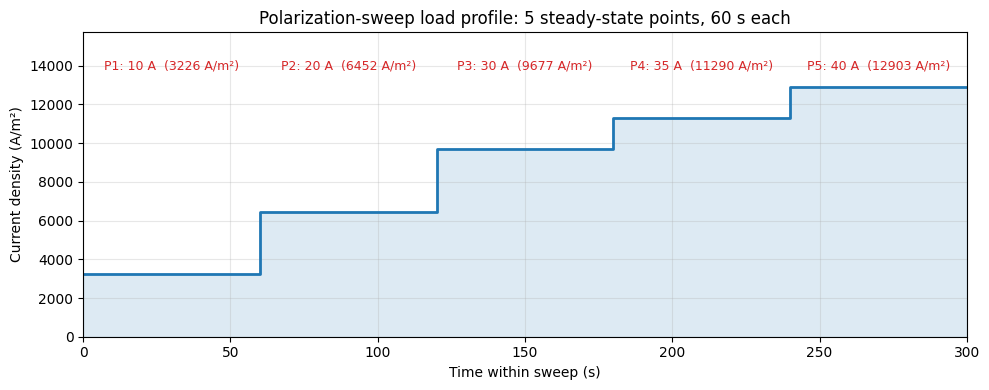

For each polar point we hold a constant load for 60 s:
  P1:  I =  10.0 A  ->  i =  3225.8 A/m²
  P2:  I =  20.0 A  ->  i =  6451.6 A/m²
  P3:  I =  30.0 A  ->  i =  9677.4 A/m²
  P4:  I =  35.0 A  ->  i = 11290.3 A/m²
  P5:  I =  40.0 A  ->  i = 12903.2 A/m²


In [7]:
# ---- Cell 5: Load profile used to generate each polarization point ----
# Each polar point is a constant current held for `t_hold` seconds; the
# staircase below visualises the load schedule on a single time axis.

t_hold = dwell_polar  # Keep in sync with simulate_polar()
i_A_per_m2 = [I / parameters["Aact"] for I in I_tested]

# Build the staircase
t_stairs, i_stairs = [], []
t0 = 0.0
for i_density in i_A_per_m2:
    t_stairs += [t0, t0 + t_hold]
    i_stairs += [i_density, i_density]
    t0 += t_hold

fig, ax = plt.subplots(figsize=(10, 4))
ax.step(t_stairs, i_stairs, where="post", linewidth=2, color="tab:blue")
ax.fill_between(t_stairs, 0, i_stairs, step="post", alpha=0.15, color="tab:blue")
y_top = max(i_stairs) * 1.06
for k, (I, i_d) in enumerate(zip(I_tested, i_A_per_m2)):
    t_mid = (k + 0.5) * t_hold
    label = "P" + str(k + 1) + ": " + str(I) + " A  (" + format(i_d, ".0f") + " A/m²)"
    ax.text(t_mid, y_top, label, ha="center", va="bottom", fontsize=9, color="tab:red", rotation=0)
ax.set_xlim(0, len(I_tested) * t_hold)
ax.set_ylim(0, y_top * 1.15)
ax.set_xlabel("Time within sweep (s)")
ax.set_ylabel("Current density (A/m²)")
ax.set_title("Polarization-sweep load profile: "
             + str(len(I_tested)) + " steady-state points, "
             + format(t_hold, "g") + " s each")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("For each polar point we hold a constant load for", format(t_hold, "g"), "s:")
for k, (I, i_d) in enumerate(zip(I_tested, i_A_per_m2), 1):
    print("  P" + str(k) + ":  I = " + format(I, "5.1f") + " A  ->  i = "
          + format(i_d, "7.1f") + " A/m²")

Simulating T60_P400_HRC50 ...
299.999999999
  T60_P400_HRC50: 5/5 points OK   (single solve, avg 3.76 s/point)


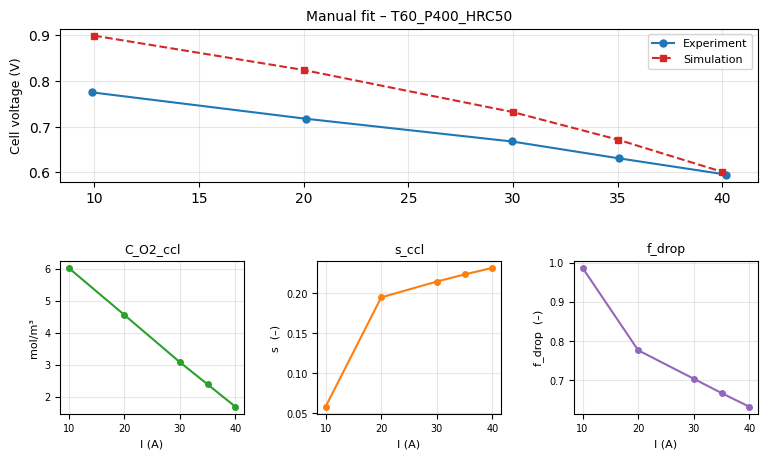

Compared 5 experimental points against 5 simulation points.
RMSE on 5 points: 80.9 mV


In [8]:

# ---- Cell 6: Plot one-condition fit ----
# Change CHOSEN_COND to any key printed by cell 2.
CHOSEN_COND = "T60_P400_HRC50"
print(f"Simulating {CHOSEN_COND} ...")

# Experimental
df = polardata_exp[CHOSEN_COND]
i_exp_full = df["I_LOAD"].to_numpy(dtype=float)
v_exp_full = df["VFC"].to_numpy(dtype=float) / n_cell

# Simulation with current manual_params
i_sim, v_sim, internals = simulate_polar(CHOSEN_COND, manual_params)
i_exp, v_exp = match_experimental_points(i_exp_full, v_exp_full, i_sim)

# --- Figure: polar curve (top, full-width) + 3 diagnostics (bottom row) ---
fig = plt.figure(figsize=(9, 5))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.52, wspace=0.40)
ax_polar = fig.add_subplot(gs[0, :])
ax_co2   = fig.add_subplot(gs[1, 0])
ax_s     = fig.add_subplot(gs[1, 1])
ax_fd    = fig.add_subplot(gs[1, 2])

# Polarization curve
if len(i_exp):
    ax_polar.plot(i_exp, v_exp, "o-", color="tab:blue", markersize=5, label="Experiment")
if i_sim:
    ax_polar.plot(i_sim, v_sim, "s--", color="tab:red", markersize=5, label="Simulation")
ax_polar.set_ylabel("Cell voltage (V)", fontsize=9)
ax_polar.set_title(f"Manual fit – {CHOSEN_COND}", fontsize=10)
ax_polar.grid(True, alpha=0.3)
ax_polar.legend(loc="best", fontsize=8)

# Diagnostic subplots (simulation points only)
if i_sim:
    ax_co2.plot(i_sim, internals["C_O2_ccl"], "o-", color="tab:green", markersize=4)
    ax_co2.set_ylabel("mol/m³", fontsize=8)
    ax_co2.set_xlabel("I (A)", fontsize=8)
    ax_co2.set_title("C_O2_ccl", fontsize=9)
    ax_co2.grid(True, alpha=0.3)
    ax_co2.tick_params(labelsize=7)

    ax_s.plot(i_sim, internals["s_ccl"], "o-", color="tab:orange", markersize=4)
    ax_s.set_ylabel("s  (–)", fontsize=8)
    ax_s.set_xlabel("I (A)", fontsize=8)
    ax_s.set_title("s_ccl", fontsize=9)
    ax_s.grid(True, alpha=0.3)
    ax_s.tick_params(labelsize=7)

    ax_fd.plot(i_sim, internals["fdrop"], "o-", color="tab:purple", markersize=4)
    ax_fd.set_ylabel("f_drop  (–)", fontsize=8)
    ax_fd.set_xlabel("I (A)", fontsize=8)
    ax_fd.set_title("f_drop", fontsize=9)
    ax_fd.grid(True, alpha=0.3)
    ax_fd.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

# RMSE on the aligned comparison points only
if i_sim:
    rmse = float(np.sqrt(np.mean((np.array(v_sim) - v_exp) ** 2)))
    print(f"Compared {len(i_exp)} experimental points against {len(i_sim)} simulation points.")
    print(f"RMSE on {len(i_sim)} points: {rmse * 1000:.1f} mV")
else:
    print("No simulation points succeeded -- check the parameters in cell 4.")


Simulating T60_P300_HRC50 ...
299.999999999
  T60_P300_HRC50: 5/5 points OK   (single solve, avg 3.36 s/point)
Simulating T70_P300_HRC50 ...
299.999999999
  T70_P300_HRC50: 5/5 points OK   (single solve, avg 4.01 s/point)


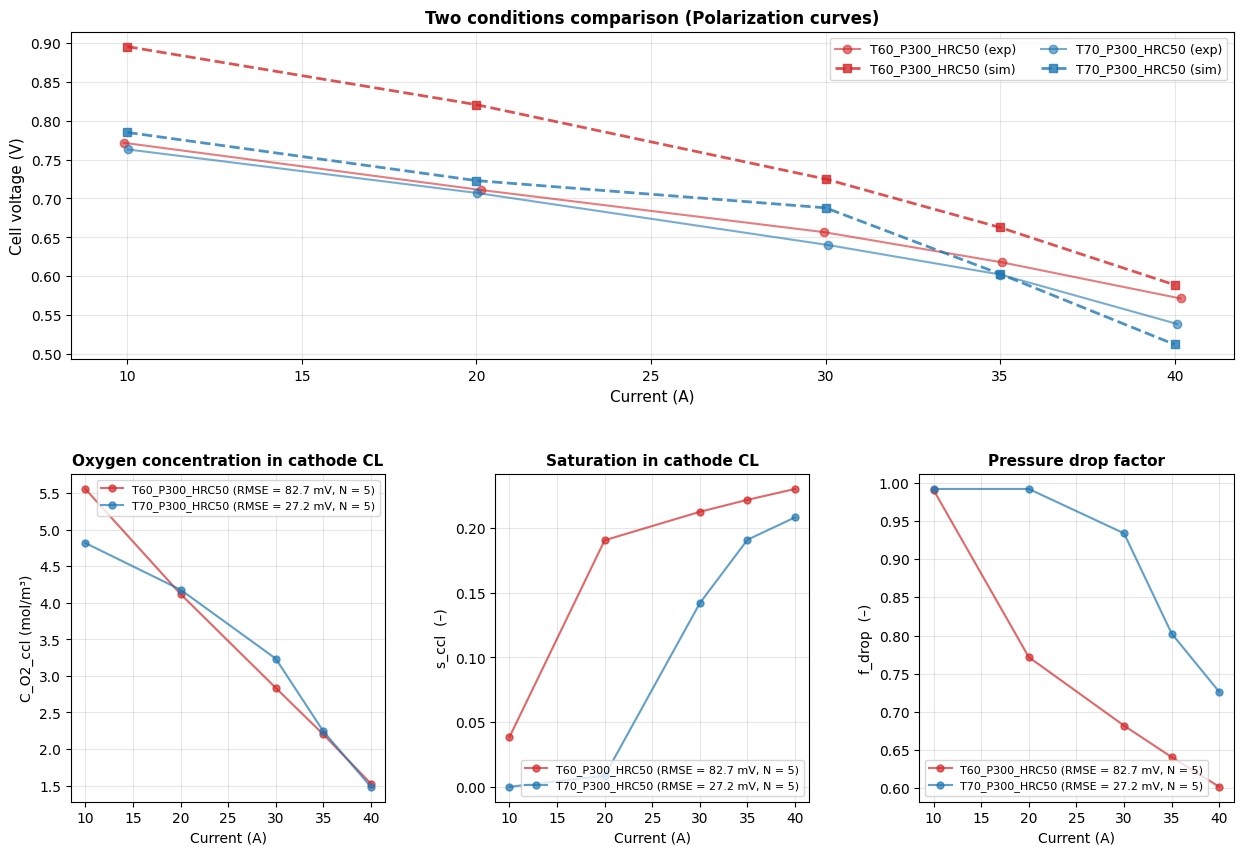

T60_P300_HRC50: compared 5 experimental points against 5 simulation points.
T70_P300_HRC50: compared 5 experimental points against 5 simulation points.


In [9]:
# ---- Cell 7: Plot two-condition fit with internal states overlaid ----
CHOSEN_2 = ["T60_P300_HRC50", "T70_P300_HRC50"]

fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.35)
ax_polar = fig.add_subplot(gs[0, :])
ax_co2   = fig.add_subplot(gs[1, 0])
ax_s     = fig.add_subplot(gs[1, 1])
ax_fd    = fig.add_subplot(gs[1, 2])

# Storage for all data
all_results = {}
colors = {"T60_P300_HRC50": "tab:red", "T70_P300_HRC50": "tab:blue"}

# Simulate both conditions
for cond_key in CHOSEN_2:
    print(f"Simulating {cond_key} ...")
    df = polardata_exp[cond_key]
    i_exp_full = df["I_LOAD"].to_numpy(dtype=float)
    v_exp_full = df["VFC"].to_numpy(dtype=float) / n_cell
    i_sim, v_sim, internals = simulate_polar(cond_key, manual_params)
    i_exp, v_exp = match_experimental_points(i_exp_full, v_exp_full, i_sim)

    all_results[cond_key] = {
        "i_exp": i_exp,
        "v_exp": v_exp,
        "i_sim": i_sim,
        "v_sim": v_sim,
        "internals": internals,
    }

    # Plot polarization curves on shared plot
    if len(i_exp):
        ax_polar.plot(i_exp, v_exp, "o-", color=colors[cond_key], markersize=6, label=f"{cond_key} (exp)", alpha=0.6, linewidth=1.5)
    if i_sim:
        ax_polar.plot(i_sim, v_sim, "s--", color=colors[cond_key], markersize=6, label=f"{cond_key} (sim)", alpha=0.8, linewidth=2)

ax_polar.set_ylabel("Cell voltage (V)", fontsize=11)
ax_polar.set_xlabel("Current (A)", fontsize=11)
ax_polar.set_title("Two conditions comparison (Polarization curves)", fontsize=12, fontweight="bold")
ax_polar.grid(True, alpha=0.3)
ax_polar.legend(loc="best", fontsize=9, ncol=2)

# Plot internal states for both conditions overlaid
for cond_key, color in colors.items():
    i_sim = all_results[cond_key]["i_sim"]
    i_exp = all_results[cond_key]["i_exp"]
    v_exp = all_results[cond_key]["v_exp"]
    v_sim = all_results[cond_key]["v_sim"]
    internals = all_results[cond_key]["internals"]

    if i_sim:
        rmse = float(np.sqrt(np.mean((np.array(v_sim) - v_exp) ** 2)))
        rmse_str = f"RMSE = {rmse * 1000:.1f} mV, N = {len(i_exp)}"
        label = f"{cond_key} ({rmse_str})"

        ax_co2.plot(i_sim, internals["C_O2_ccl"], "o-", color=color, markersize=5, label=label, linewidth=1.5, alpha=0.7)
        ax_s.plot(i_sim, internals["s_ccl"], "o-", color=color, markersize=5, label=label, linewidth=1.5, alpha=0.7)
        ax_fd.plot(i_sim, internals["fdrop"], "o-", color=color, markersize=5, label=label, linewidth=1.5, alpha=0.7)

# Format diagnostic plots
ax_co2.set_ylabel("C_O2_ccl (mol/m³)", fontsize=10)
ax_co2.set_xlabel("Current (A)", fontsize=10)
ax_co2.set_title("Oxygen concentration in cathode CL", fontsize=11, fontweight="bold")
ax_co2.grid(True, alpha=0.3)
ax_co2.legend(fontsize=8, loc="best")

ax_s.set_ylabel("s_ccl  (–)", fontsize=10)
ax_s.set_xlabel("Current (A)", fontsize=10)
ax_s.set_title("Saturation in cathode CL", fontsize=11, fontweight="bold")
ax_s.grid(True, alpha=0.3)
ax_s.legend(fontsize=8, loc="best")

ax_fd.set_ylabel("f_drop  (–)", fontsize=10)
ax_fd.set_xlabel("Current (A)", fontsize=10)
ax_fd.set_title("Pressure drop factor", fontsize=11, fontweight="bold")
ax_fd.grid(True, alpha=0.3)
ax_fd.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()

for cond_key in CHOSEN_2:
    i_exp = all_results[cond_key]["i_exp"]
    i_sim = all_results[cond_key]["i_sim"]
    print(f"{cond_key}: compared {len(i_exp)} experimental points against {len(i_sim)} simulation points.")